# 3n-MRC Analysis

In [25]:
# import
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import MDAnalysis as mda
import xarray as arr
import mdtraj as md
import scipy
from MDAnalysis.analysis import distances

In [26]:
# paths to simulations
path1 = "/data/geissler/simulations/rec_lig/3n-mrc/1rep/"  # path to replica1
path2 = "/data/geissler/simulations/rec_lig/3n-mrc/2rep/"  # path to replica2
path3 = "/data/geissler/simulations/rec_lig/3n-mrc/3rep/"  # path to replica3
path_combined = "/data/geissler/simulations/rec_lig/3n-mrc/combined/"  # path to folder with concatenated version of all 3 replicas
path_stats = "/data/geissler/simulations/rec_lig/3n-mrc/combined/stats/"  # path to save results

## RMSD Calcium and Ligand to pocket

### Cal to pocket

RMSD was calculated with gromacs using the protein backbone as the group for least squares fit and the Calcium atom for the RMSD calculation. The trajectory was centered on the pocket atoms, otherwise the calcium atoms jumps in and out of the box.

In [37]:
# load data
rmsd_cal_center = np.loadtxt(f"{path_stats}cal_center_rmsd.xvg",
                     comments =['#','@'])
rmsd_cal_center[:, 0] = np.arange(0, len(rmsd_cal_center))
rmsd_lig = np.loadtxt(f"{path_stats}rmsd_lig.xvg",
                     comments =['#','@'])
rmsd_lig[:, 0] = np.arange(0, len(rmsd_cal_center))

In [38]:
# smooth RMSD over 20 frames
def movingaverage(values, window):
    weights = np.repeat(1.0, window)/window
    sma = np.convolve(values, weights, 'valid')
    return sma
av = 20

In [39]:
rmean_cal = movingaverage(rmsd_cal_center[:,1], av)
rmean_lig = movingaverage(rmsd_lig[:,1], av)

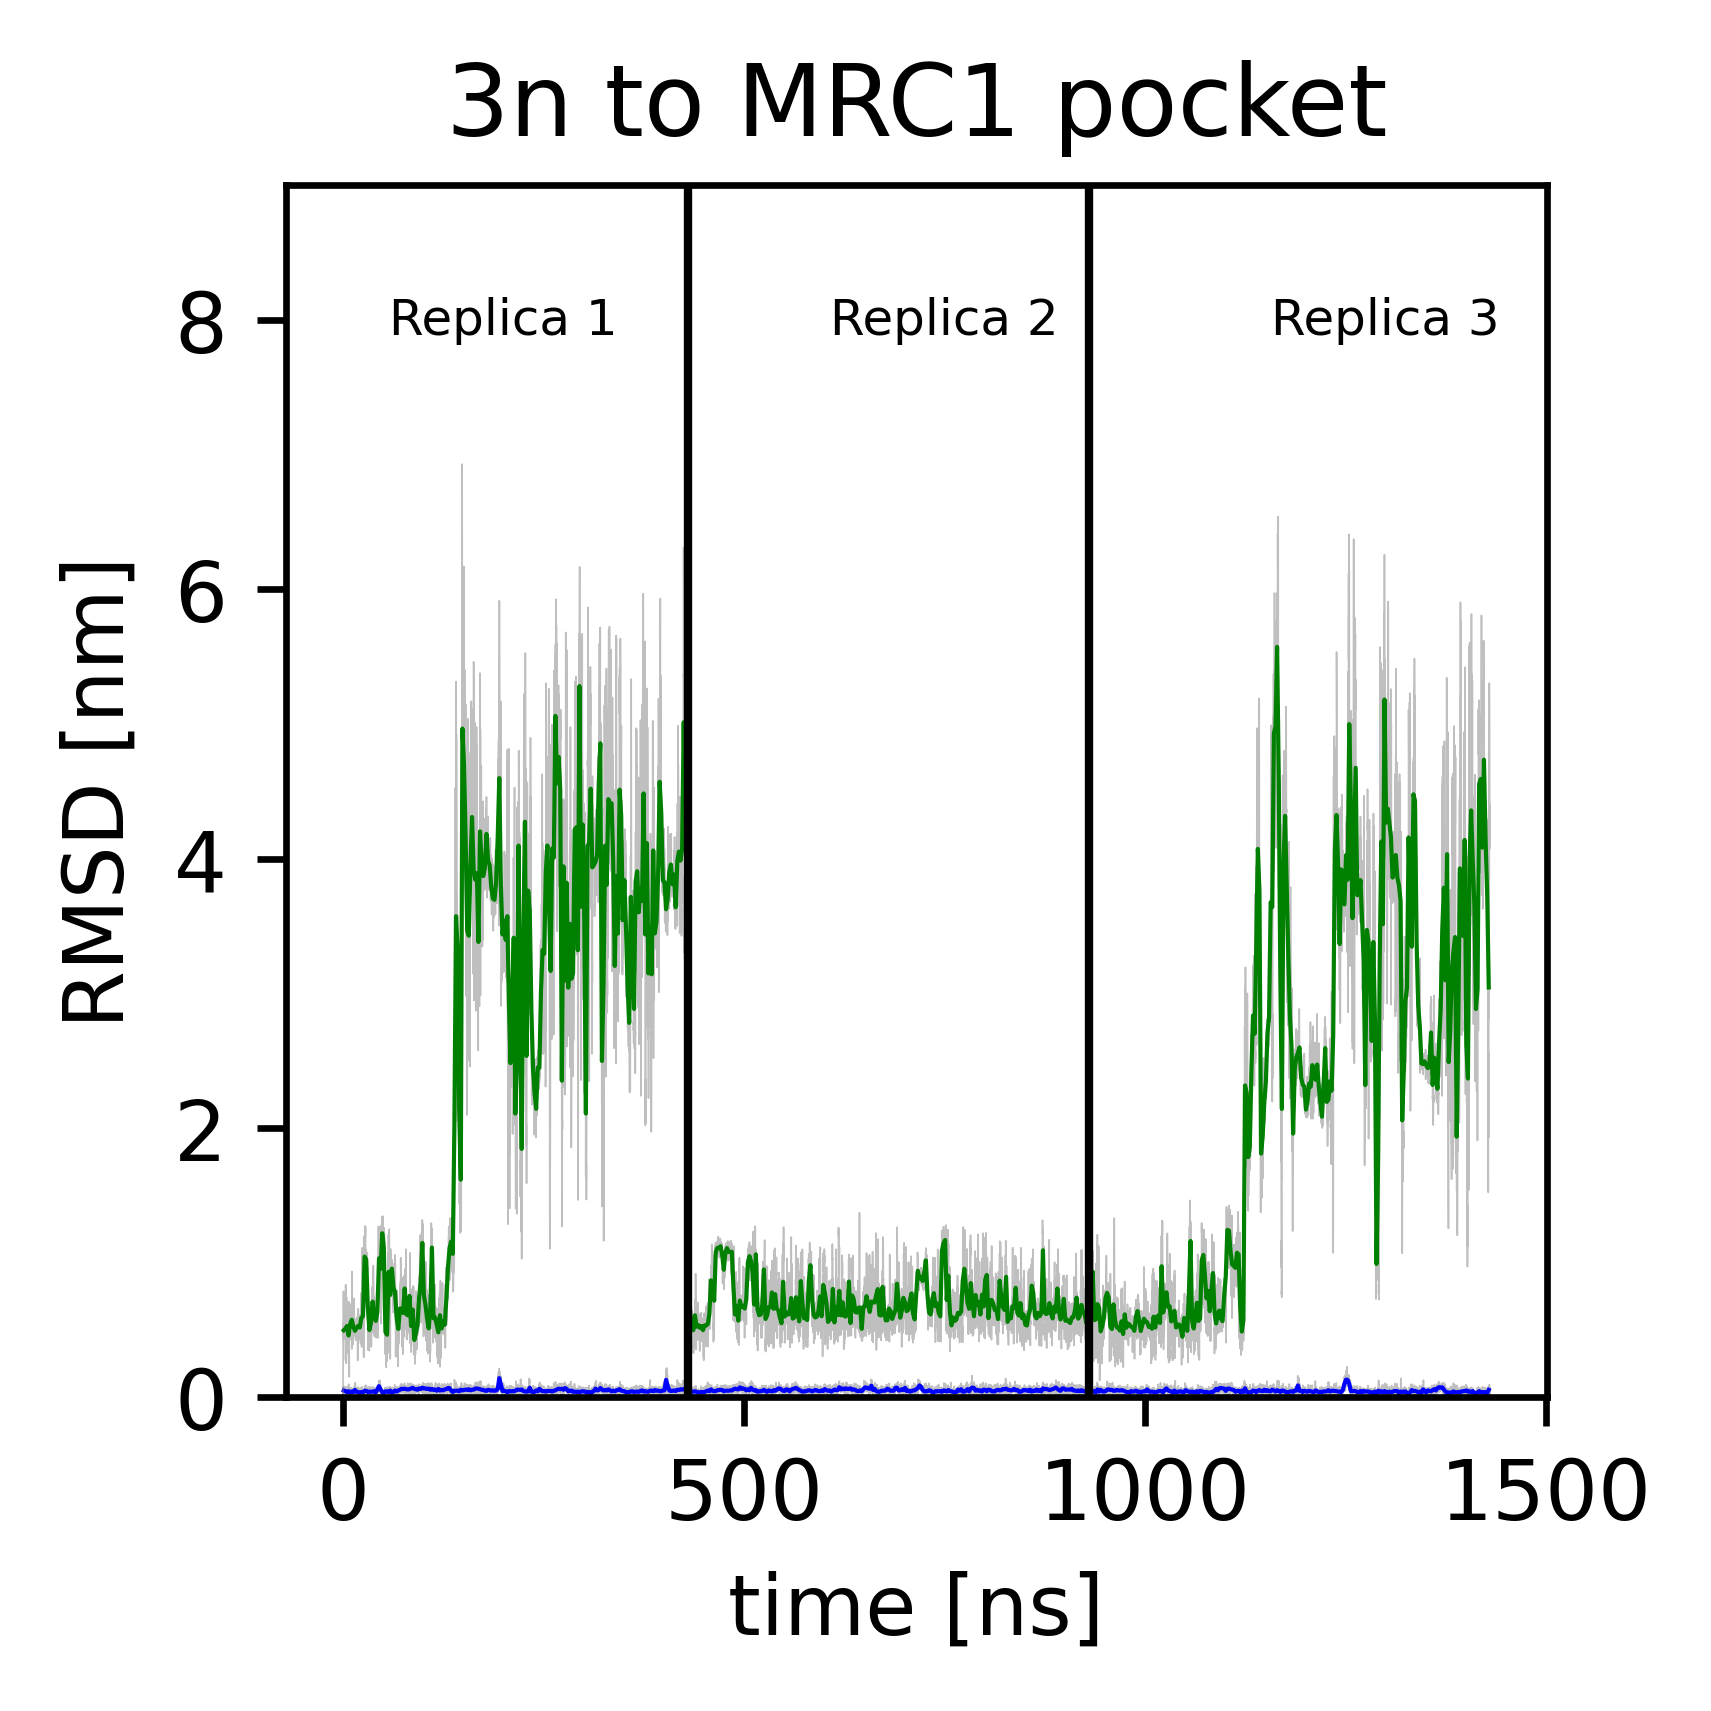

In [42]:
# plot RMSD
cm = 1/2.54
fig, ax = plt.subplots(figsize=(7.5*cm, 7.5*cm), dpi=600)

ax.plot(rmsd_cal_center.T[1], linewidth=0.2, c='grey', alpha=0.5)  # RMSD Cal
ax.plot(rmsd_cal_center[int(av/2-1):-int(av/2),0][::av]/1, rmean_cal[::av], linewidth=0.5, c='#0000FF') # smoothed RMSD Cal
ax.plot(rmsd_lig.T[1], linewidth=0.2, c='grey', alpha=0.5)  # RMSD lig
ax.plot(rmsd_lig[int(av/2-1):-int(av/2),0][::av]/1, rmean_lig[::av], linewidth=0.5, c='green') # smoothed RMSD lig
plt.axvline(4300, color='#000000', linewidth=1)  # borders between replica
plt.axvline(9300, color='#000000', linewidth=1)

plt.text(2000, 8, "Replica 1", size=6, rotation=0.,  # labels
         ha="center", va="center",
         bbox=dict(boxstyle="round",
                   ec=(1, 1, 1),
                   fc=(1,1,1),))
plt.text(7500, 8, "Replica 2", size=6, rotation=0.,
         ha="center", va="center",
         bbox=dict(boxstyle="round",
                   ec=(1, 1, 1),
                   fc=(1,1,1),))
plt.text(13000, 8, "Replica 3", size=6, rotation=0.,
         ha="center", va="center",
         bbox=dict(boxstyle="round",
                   ec=(1, 1, 1),
                   fc=(1,1,1),))

ax.set_ylim(0,9)
# ax.set_xlim(0,15010)
plt.xticks([0, 5000, 10000, 15000,], ['0', '500', '1000', '1500',], fontsize=10)
plt.title('3n to MRC1 pocket')
ax.set_xlabel('time [ns]')
ax.set_ylabel('RMSD [nm]')
plt.tight_layout()
plt.savefig("/data/geissler/analysis/RMSD/cal_lig/3n-mrc.png")

## different binding states (for Figure 6)

Here I define the different binding conformations ("binding states") by distances of different mannose Hydroxy-groups to different amino acids in the binding pocket of the receptor: 
<br> 
(the different HO-groups are hightlighted in Fig.5 of the paper)
- the "crystal state" is defined by HO4 being close to Glu725, HO3 being close to Glu733, HO6 being far away from Glu737 and HO2 being far away from Glu725
- "state A" is defined by HO2 being close to Glu725, HO4 being far from Glu725, HO6 being far from Glu737 and HO2 being far from Glu733
- "state B" is defined by HO2 being close to Glu733, HO4 being far from Glu725, HO6 being far from Glu737 and HO2 being far from Glu725
- "state C" is defined by HO6 being close to Glu737, HO3 being close to Glu733 and HO2 being far from Glu725 

In [3]:
# for the calculations I concatenated all frames of ligand being bound to the pocket
traj = mda.Universe(path_combined+'md_500ns.pdb',
                   path_combined+'combined_bound.xtc')

As I define the binding states by distances, I calculate the different distances between HO atoms and the respective amino acids

In [4]:
# this calculates the distance between the two defined atoms below for each frame of the simulation and appends them to a list
# distance 1: HO6 to Glutamic Acid 737
man = traj.select_atoms('resname LIG and name HO6')
prot = traj.select_atoms('protein and resid 737 and name CD') 

distance1 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance1.append(dist_arr/10)  # convert from Angstr. to nm

In [5]:
# distance 2: HO2 to Glutamic Acid 725
man = traj.select_atoms('resname LIG and name HO2')
prot = traj.select_atoms('protein and resid 725 and name CD')

distance2 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance2.append(dist_arr/10)  # convert from Angstr. to nm

In [6]:
# distance 3: HO3 to Glutamic Acid 733
man = traj.select_atoms('resname LIG and name HO3')
prot = traj.select_atoms('protein and resid 733 and name CD')

distance3 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance3.append(dist_arr/10)  # convert from Angstr. to nm

In [7]:
# distance 4: HO4 to Glutamic Acid 725 
man = traj.select_atoms('resname LIG and name HO4')
prot = traj.select_atoms('protein and resid 725 and name CD')

distance4 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance4.append(dist_arr/10)  # convert from Angstr. to nm

In [8]:
# distance 5: HO2 to Glutamic Acid 733
man = traj.select_atoms('resname LIG and name HO2')  
prot = traj.select_atoms('protein and resid 733 and name CD')

distance5 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance5.append(dist_arr/10)  # convert from Angstr. to nm

In [9]:
# now I put them into 1 array
all_distances=np.column_stack((distance1,distance2,distance3,distance4,distance5))
# and make it flat
distances_flat=all_distances[:,:,0]
np.save('distances_flat.npy', distances_flat)

Now I sort the frames into their respective state. I defined the cutoff between close and far at 3.5 Ångström which roughliy corresponds to the length of a hydrogen bond.

In [10]:
# crystal state: HO4 close to Glu725, HO3 close to Glu733, HO6 far away from Glu737 and HO2 far away from Glu725
crystal = []
for i, j in enumerate(distances_flat):
    if distances_flat[i][3] <= 0.35 and distances_flat[i][2] <= 0.35 and distances_flat[i][0] > 0.35 and distances_flat[i][1] > 0.35:
        crystal.append(i)
print(len(crystal))  # print how many frames correspond to the crystal state

3101


In [11]:
# state A: HO2 close to Glu725, HO4 far from Glu725, HO6 far from Glu737 and HO2 far from Glu733
stateA = []
for i, j in enumerate(distances_flat):
    if distances_flat[i][1] <= 0.35 and distances_flat[i][3] > 0.35 and  distances_flat[i][0] > 0.35 and distances_flat[i][4] > 0.35:
        stateA.append(i)
print(len(stateA))

1


In [12]:
# state B: HO2 close to Glu733, HO4 far from Glu725, HO6 far from Glu737 and HO2 far from Glu725
stateB = []
for i, j in enumerate(distances_flat):
    if distances_flat[i][4] <= 0.35 and distances_flat[i][3] > 0.35 and distances_flat[i][0] > 0.35 and distances_flat[i][1] > 0.35:
        stateB.append(i)
print(len(stateB))

421


In [13]:
# state C: HO6 close to Glu737, HO3 close to Glu733 and HO2 far from Glu725
stateC = []
for i, j in enumerate(distances_flat):
    if distances_flat[i][0] <= 0.35 and distances_flat[i][2] <= 0.35 and distances_flat[i][1] > 0.35:
        stateC.append(i)
print(len(stateC))

4212


In [14]:
# this is how I find out how many frames do not fall into any defined state ("others")
len(distances_flat)-len(crystal)-len(stateA)-len(stateB)-len(stateC)

558

## get frames of specific states to make a trajectory

For mmPBSA calculation for the specific states and for producing state contact maps, I will bin the frames of the same state together into one state specific trajectory. 
<br>
I will make trajectories between 100 and 300 frames, to have better comparability.
<br>
By multiplying the frame numbers with 100 ps and considering the order of replicas, I can use the output below directly as input for the 'states_trajectory.sh' bash script.

This is what the combined bound traj is made of:

- 1rep bound: 1391 frames, 139 ns, 139100 ps
- 2rep bound: 5001 frames, 500 ns, 500100 ps
- 3rep bound: 1901 frames, 190 ns, 190100 ps

  8293 frames in total -> 829300 ps

### crystal state

In [16]:
ps = 100
crystal_ps= [x*ps for x in crystal] 
print(*crystal_ps[:300])

0 100 200 300 400 500 600 700 800 900 1000 1100 1200 1300 1400 1500 1600 1700 1800 1900 2000 2100 2200 2300 2400 2500 2600 2700 2900 3000 3100 3200 3300 3400 3500 3600 3700 3900 4000 4100 4200 4600 4700 4800 5300 5400 5500 5600 5700 5800 5900 6000 6100 6200 6300 6400 6500 6600 6700 7400 7500 7600 7700 7800 7900 8000 8100 8200 8300 8400 8500 8600 8700 8800 8900 9000 9100 9200 9300 9400 9500 9700 9900 10000 10200 10300 10400 10500 10600 10700 10800 10900 11000 11100 11200 11300 11400 11500 11600 11700 11800 11900 12000 12100 12200 12300 12400 12500 12600 12700 12800 12900 13000 13100 13200 13300 13400 13800 13900 14000 14100 14200 14300 14400 14500 14600 14700 14800 14900 15000 15100 15200 15300 15400 15500 15600 15700 15800 15900 16000 16100 16200 16300 16400 16500 16700 16800 16900 17000 17100 17200 17300 17400 17500 17600 17700 17800 17900 18000 18100 18300 18400 18500 18600 18700 18800 18900 19000 19100 19200 19300 19400 19500 19600 19700 19800 19900 20000 20100 20200 20300 20400 205

The first 300 frames are all in replica 1.

### state A has less than 100 frames

### state B

In [17]:
ps = 100
stateB_ps= [x*ps for x in stateB] 
print(*stateB_ps[:300])

2800 3800 4300 4400 4500 4900 5000 5100 5200 6800 6900 7000 7100 7200 7300 9600 9800 10100 13500 13600 13700 16600 18200 30900 37300 51900 52200 52300 52400 52800 52900 53500 53800 53900 54000 54100 54200 54300 54400 54500 55100 55200 55300 55400 55500 55600 55700 55800 55900 56000 56100 58200 63600 63700 66700 67500 67600 67900 68000 70500 70600 71500 72500 83600 88000 91400 104800 105800 106000 106100 106200 106300 106400 106500 106600 106700 106800 106900 107000 107100 107200 107300 107400 107500 108400 108500 108600 114200 114300 114400 114500 114600 114700 114800 114900 116100 142300 156100 156300 157900 158100 159700 159800 160000 161100 163000 163100 163200 163300 163700 167500 167600 167800 167900 168100 168300 237500 238800 242000 242300 242800 243000 243100 325700 332400 417800 418500 418600 418900 419100 419200 419300 428200 428300 428900 430500 430700 431900 432500 432600 433400 434400 434500 554600 557600 557800 593500 614200 640200 643900 645000 645600 647400 647600 64790

In [18]:
print('frames in 1rep:')
for i in stateB_ps[:300]:
    if i <= 139100:
        print(i)

frames in 1rep:
2800
3800
4300
4400
4500
4900
5000
5100
5200
6800
6900
7000
7100
7200
7300
9600
9800
10100
13500
13600
13700
16600
18200
30900
37300
51900
52200
52300
52400
52800
52900
53500
53800
53900
54000
54100
54200
54300
54400
54500
55100
55200
55300
55400
55500
55600
55700
55800
55900
56000
56100
58200
63600
63700
66700
67500
67600
67900
68000
70500
70600
71500
72500
83600
88000
91400
104800
105800
106000
106100
106200
106300
106400
106500
106600
106700
106800
106900
107000
107100
107200
107300
107400
107500
108400
108500
108600
114200
114300
114400
114500
114600
114700
114800
114900
116100


In [19]:
print('frames in 2rep:')
for i in stateB_ps[:500]:
    if i > 139100 and i <= (139100+500100):
        print(i-139100)

frames in 2rep:
3200
17000
17200
18800
19000
20600
20700
20900
22000
23900
24000
24100
24200
24600
28400
28500
28700
28800
29000
29200
98400
99700
102900
103200
103700
103900
104000
186600
193300
278700
279400
279500
279800
280000
280100
280200
289100
289200
289800
291400
291600
292800
293400
293500
294300
295300
295400
415500
418500
418700
454400
475100


In [20]:
print('frames in 3rep:')
for i in stateB_ps[:500]:
    if i > (139100+500100):
        print(i-(139100+500100))

frames in 3rep:
1000
4700
5800
6400
8200
8400
8700
9000
9100
9200
9600
10200
10600
10800
11000
11300
11400
12600
15600
15700
16600
18900
21200
22600
22700
22800
22900
29300
29400
29700
30100
32800
32900
33300
33500
33600
33800
33900
34000
34100
34200
34300
34500
34600
34700
34800
36000
39400
43200
48000
48300
48600
49000
51500
51600
51700
54500
56900
57600
57900
58000
58200
58500
58600
58700
58900
59100
59300
59800
59900
60000
60100
60400
60600
60700
60800
61000
61100
61400
61500
61600
61900
62000
62200
62400
75000
75100
77100
77300
77400
77700
78000
86200
87000
87100
87200
87300
87400
87800
88400
88500
88700
94100
101800
102900
103400
106700
106800
106900
113400
115100
116800
117800
118800
119700
120100
120200
120300
120400
120500
120600
120800
120900
131800
132600
135300
138300
138400
138500
138600
138800
138900
139000
139100
139200
139300
139400
139500
139600
139700
139800
139900
140000
140100
140200
140300
140400
140500
140600
140700
140800
140900
141000
141100
141200
141300
141400

### state C

In [21]:
ps = 100
stateC_ps= [x*ps for x in stateC] 
print(*stateC_ps[:300])

168000 168200 168400 168500 168600 168700 168800 168900 169000 169100 169200 169300 169400 169500 169600 169700 169800 169900 170000 170100 170200 170300 170400 170500 170600 170700 170800 170900 171000 171100 171200 171300 171400 171500 171600 171700 171800 171900 172000 172100 172200 172300 172400 172500 172600 172700 172800 172900 173000 173100 173200 173300 173400 173500 173600 173700 173800 173900 174000 174100 174200 174300 174400 174500 174600 174700 174800 174900 175000 175100 175200 175300 175400 175500 175600 175700 175800 175900 176000 176100 176200 176300 176400 176500 176600 176700 176800 176900 177000 177100 177300 177400 177500 177600 177700 177800 177900 178000 178100 178200 178300 178400 178500 178600 178700 178800 178900 179000 179100 179200 179300 179400 179500 179600 179700 179800 179900 180000 180100 180200 180300 180400 180500 180600 180700 180800 180900 181000 181100 181200 181300 181400 181500 181600 181700 181800 181900 182000 182100 182200 182300 182400 182500

In [24]:
# how many frames in replica 2?
print('frames in 2rep:')
for i in stateC_ps[:300]:
    if i > 139100 and i <= (139100+500100):
        print(i-139100)

frames in 2rep:
28900
29100
29300
29400
29500
29600
29700
29800
29900
30000
30100
30200
30300
30400
30500
30600
30700
30800
30900
31000
31100
31200
31300
31400
31500
31600
31700
31800
31900
32000
32100
32200
32300
32400
32500
32600
32700
32800
32900
33000
33100
33200
33300
33400
33500
33600
33700
33800
33900
34000
34100
34200
34300
34400
34500
34600
34700
34800
34900
35000
35100
35200
35300
35400
35500
35600
35700
35800
35900
36000
36100
36200
36300
36400
36500
36600
36700
36800
36900
37000
37100
37200
37300
37400
37500
37600
37700
37800
37900
38000
38200
38300
38400
38500
38600
38700
38800
38900
39000
39100
39200
39300
39400
39500
39600
39700
39800
39900
40000
40100
40200
40300
40400
40500
40600
40700
40800
40900
41000
41100
41200
41300
41400
41500
41600
41700
41800
41900
42000
42100
42200
42300
42400
42500
42600
42700
42800
42900
43000
43100
43200
43300
43400
43500
43600
43700
43800
43900
44000
44100
44200
44300
44400
44500
44600
44700
44800
44900
45000
45100
45200
45300
45400
45500
